In [17]:
import pandas             as pd
import numpy              as np
import matplotlib.pyplot  as plt
import seaborn            as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

from sklearn.model_selection    import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing      import StandardScaler, PolynomialFeatures
from sklearn.neighbors          import KNeighborsRegressor
from sklearn.linear_model       import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble           import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection  import SelectKBest, f_regression, RFE
from sklearn.metrics            import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline           import Pipeline

import warnings
warnings.filterwarnings('ignore')

In [18]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset/Life Expectancy Data.csv')

# replace
df.columns = df.columns.str.strip().str.replace(' ', '_', regex=False)

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,...,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness__1-19_years,thinness_5-9_years,Income_composition_of_resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life_expectancy                  2928 non-null   float64
 4   Adult_Mortality                  2928 non-null   float64
 5   infant_deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage_expenditure           2938 non-null   float64
 8   Hepatitis_B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five_deaths                2938 non-null   int64  
 12  Polio               

Размер данных за 2014 год: (183, 22)
Количество стран:          183

del Country

Пропуски в данных за 2014 год:
                                 Пропусков  Процент
Population                              41    22.40
GDP                                     28    15.30
Hepatitis_B                             10     5.46
Income_composition_of_resources         10     5.46
Schooling                               10     5.46
thinness__1-19_years                     2     1.09
BMI                                      2     1.09
Total_expenditure                        2     1.09
thinness_5-9_years                       2     1.09
Alcohol                                  1     0.55


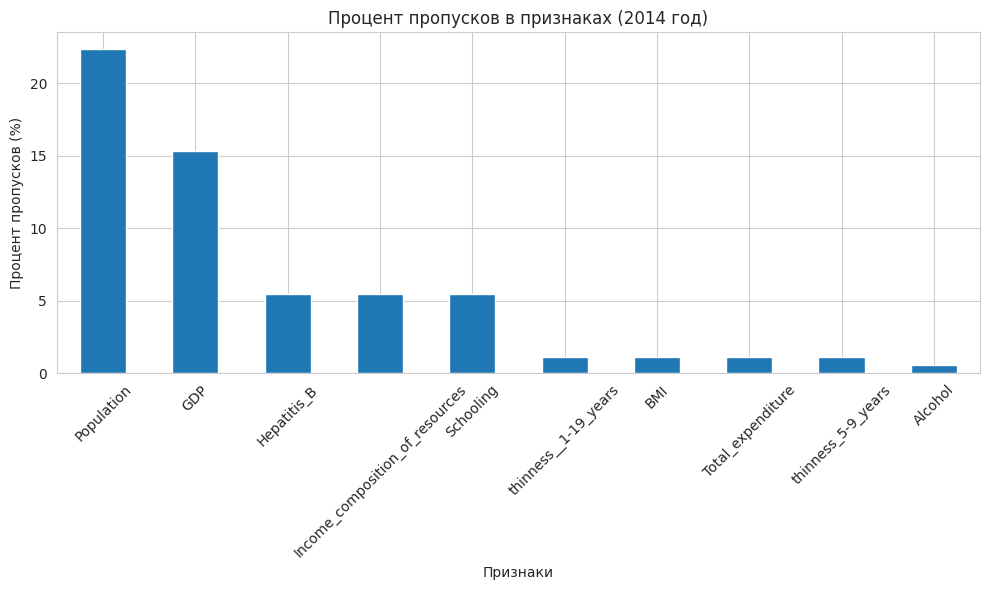

In [20]:
# оставляем 2014 год
df_2014 = df[df['Year'] == 2014].copy()

print(f"Размер данных за 2014 год: {df_2014.shape}")
print(f"Количество стран:          {df_2014['Country'].nunique()}")


# удаляем Country
if 'Country' in df_2014.columns:
    df_2014 = df_2014.drop('Country', axis=1)
    print("\ndel Country\n")

# анализ пропусков в данных за 2014 год
missing_data    = df_2014.isnull().sum()
missing_percent = (missing_data / len(df_2014)) * 100

missing_df = pd.DataFrame(
    {
    'Пропусков': missing_data,
    'Процент'  : missing_percent.round(2)
    }).sort_values('Процент', ascending=False)

print("Пропуски в данных за 2014 год:")
print(missing_df[missing_df['Пропусков'] > 0])


# Визуализация пропусков
plt.figure(figsize=(10, 6))
missing_df[missing_df['Пропусков'] > 0]['Процент'].plot(kind='bar')
plt.title('Процент пропусков в признаках (2014 год)')
plt.ylabel('Процент пропусков (%)')
plt.xlabel('Признаки')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# удаление столбцов с >10% пропусков
cols_to_drop = missing_df[missing_df['Процент'] > 10].index.tolist()
print(f"Столбцы с >10% пропусков: {cols_to_drop}")

if cols_to_drop:
    df_2014_clean = df_2014.drop(cols_to_drop, axis=1)
    print(f"\nОсталось признаков: {df_2014_clean.shape[1]}")
else:
    df_2014_clean = df_2014.copy()

Столбцы с >10% пропусков: ['Population', 'GDP']

Осталось признаков: 19


In [22]:
# Оставшиеся пропуски
print(f"Пропусков в строках: {df_2014_clean.isnull().sum().sum()}")

df_final = df_2014_clean.dropna().copy()

Пропусков в строках: 39


In [23]:
# Разделение и анализ данных для обучекния
target_col = 'Life_expectancy'
print(f"Целевая переменная: '{target_col}'\n")

X = df_final.drop(target_col, axis=1)
y = df_final[target_col]

print(f"Признаки (X):           {X.shape}")
print(f"Целевая переменная (y): {y.shape}")

Целевая переменная: 'Life_expectancy'

Признаки (X):           (163, 18)
Целевая переменная (y): (163,)


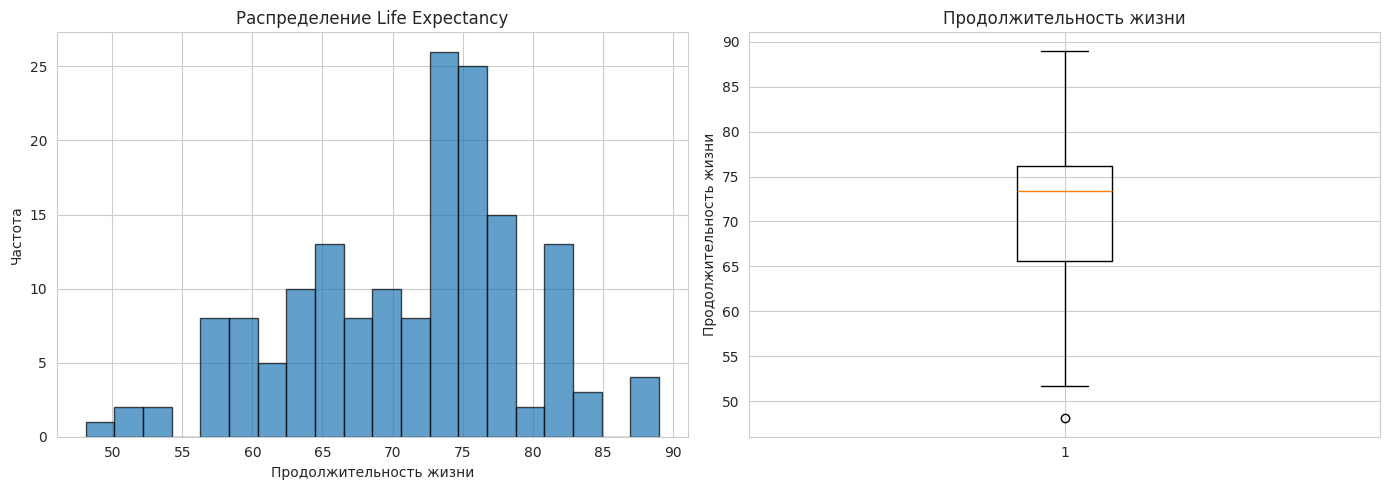

Статистика целевой переменной:
Минимум:  48.10
Максимум: 89.00
Среднее:  71.20
Медиана:  73.40


In [24]:
# Визуализация распределения целевой переменной
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(y, bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение Life Expectancy')
axes[0].set_xlabel('Продолжительность жизни')
axes[0].set_ylabel('Частота')

# Box plot
axes[1].boxplot(y)
axes[1].set_title('Продолжительность жизни')
axes[1].set_ylabel('Продолжительность жизни')

plt.tight_layout()
plt.show()

# Статистика
print(f"Статистика целевой переменной:")
print(f"Минимум:  {y.min():.2f}")
print(f"Максимум: {y.max():.2f}")
print(f"Среднее:  {y.mean():.2f}")
print(f"Медиана:  {y.median():.2f}")

In [25]:
# Разделение на обучающую и тестовую выборки (80% - обучение, 20% - тест)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки:  {X_test.shape}")

Размер обучающей выборки: (130, 18)
Размер тестовой выборки:  (33, 18)


In [26]:
# масштабирование признаков для KNN
scaler = StandardScaler()

# Только числовые признаки для масштабирования
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_test_numeric  = X_test.select_dtypes(include=[np.number])

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled  = scaler.transform(X_test_numeric)

# Обратно в DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_numeric.columns)
X_test_scaled_df  = pd.DataFrame(X_test_scaled, columns=X_test_numeric.columns)

# 2. Модель KNN

KNN - результаты: (при n_neighbors=5)
R^2:  0.7068
RMSE: 4.7773
MAE:  3.6152


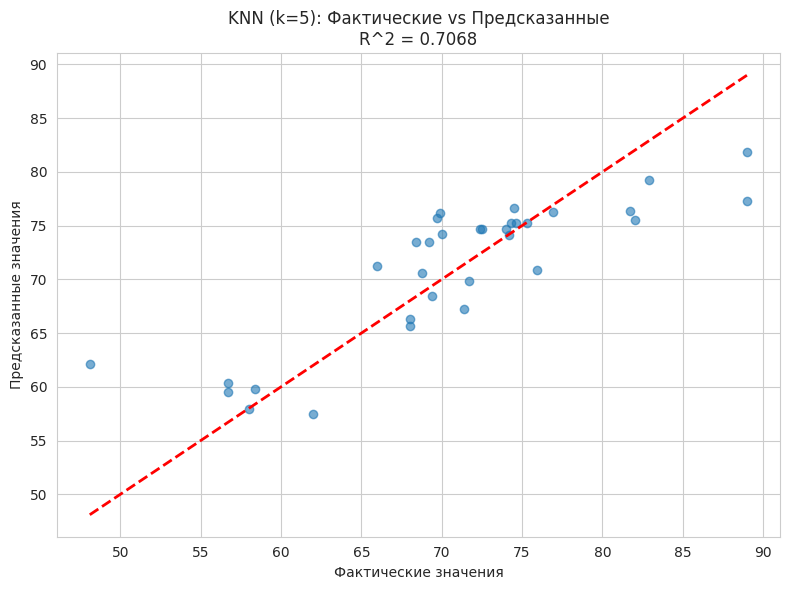

In [27]:
# обучение модели KNN с параметрами по умолчанию
knn_default = KNeighborsRegressor(n_neighbors=5)
knn_default.fit(X_train_scaled, y_train)

y_pred_knn_default = knn_default.predict(X_test_scaled)

# оценка качества
r2_knn_default   = r2_score(y_test, y_pred_knn_default)
rmse_knn_default = np.sqrt(mean_squared_error(y_test, y_pred_knn_default))
mae_knn_default  = mean_absolute_error(y_test, y_pred_knn_default)

print("KNN - результаты: (при n_neighbors=5)")
print(f"R^2:  {r2_knn_default:.4f}")
print(f"RMSE: {rmse_knn_default:.4f}")
print(f"MAE:  {mae_knn_default:.4f}")

# предсказания
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_knn_default, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title(f'KNN (k=5): Фактические vs Предсказанные\nR^2 = {r2_knn_default:.4f}')
plt.tight_layout()
plt.show()

# 3. Обучение модели линейной регрессии

Линейная регрессия - результаты:
R^2:  0.7204
RMSE: 4.6649
MAE:  3.4702


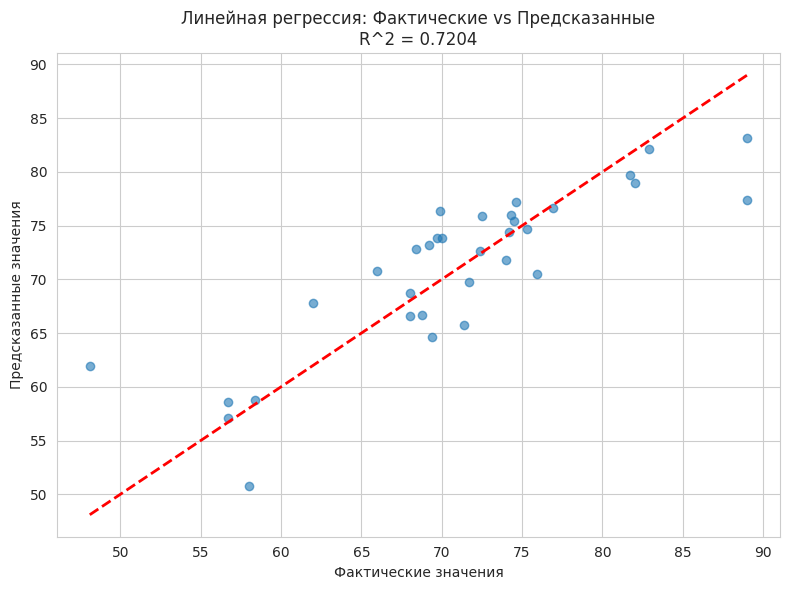

In [28]:
# модель линейной регрессии
lr_default = LinearRegression()
lr_default.fit(X_train_scaled, y_train)

# Предсказания
y_pred_lr_default = lr_default.predict(X_test_scaled)

# Оценка качества
r2_lr_default   = r2_score(y_test, y_pred_lr_default)
rmse_lr_default = np.sqrt(mean_squared_error(y_test, y_pred_lr_default))
mae_lr_default  = mean_absolute_error(y_test, y_pred_lr_default)

print("Линейная регрессия - результаты:")
print(f"R^2:  {r2_lr_default:.4f}")
print(f"RMSE: {rmse_lr_default:.4f}")
print(f"MAE:  {mae_lr_default:.4f}")


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr_default, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title(f'Линейная регрессия: Фактические vs Предсказанные\nR^2 = {r2_lr_default:.4f}')
plt.tight_layout()
plt.show()

# 4. Интерпретация результатов

**Какие были трудности с данными?**

1. Пропуски в данных: основная проблема — значительное количество пропусков в некоторых признаках. Потребовалось удалить столбцы с >10% пропусков и строки с оставшимися пропусками - это сократило объем данных для анализа.
2. Категориальные признаки: наличие признака Status (Developing/Developed) потребовало дополнительной обработки — пришлось использовать только числовые признаки для масштабирования.
3. Разномасштабность признаков: признаки имели разные единицы измерения (проценты, абсолютные числа, соотношения), что потребовало масштабирования для KNN.

**Что показали разные модели?**

1. KNN (k=5):

    R^2 = 0.7068 RMSE = 4.78 MAE = 3.62

2. Linear Regression:

    R^2 = 0.7204 RMSE = 4.66 MAE = 3.47

Сравнение:

1. Linear Regression показала немного лучший результат (R² = 0.7204 против 0.7068 у KNN)
2. Обе модели имеют схожую ошибку (RMSE ~4.7 года, MAE ~3.5 года)
3. Linear Regression лучше на 0.0136 по R², что соответствует ~1.4% относительного улучшения

**Насколько хороший результат получился?**

1. R^2 = 0.72 означает, что модель объясняет 72% дисперсии продолжительности жизни. Это хороший результат.

2. Ошибка в 3.5 года (MAE) — допустимая точность, учитывая разброс продолжительности жизни от ~50 до ~85 лет.

**Что можно было бы изменить?**

1. Удалить страны с экстремально низкой/высокой продолжительностью жизни
2. Выбрать наиболее информативные признаки


# 5. Улучшения моделей

Random Forest - результаты:
R^2:  0.8327
RMSE: 3.6082
MAE:  2.6592


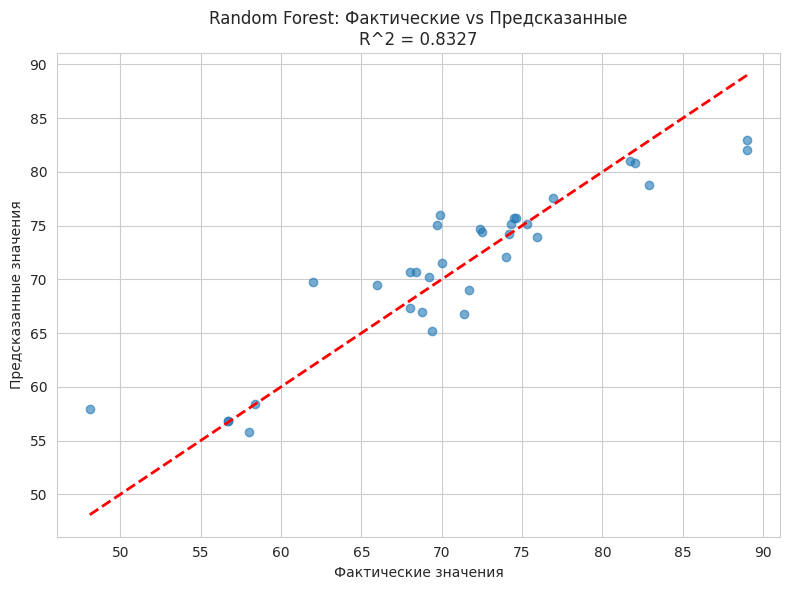

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

X_train_numeric = X_train.select_dtypes(include=[np.number])
X_test_numeric  = X_test.select_dtypes(include=[np.number])

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train_numeric, y_train)


y_pred_rf = grid_rf.predict(X_test_numeric)

r2_rf   = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest - результаты:")
print(f"R^2:  {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE:  {mae_rf:.4f}")



plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title(f'Random Forest: Фактические vs Предсказанные\nR^2 = {r2_rf:.4f}')
plt.tight_layout()
plt.show()